In [41]:
import ciropt as co
import cvxpy as cp
import numpy as np

import PEPit
import PEPit.functions as pep_func
from PEPit.constraint import Constraint as pep_constr
from PEPit.primitive_steps import proximal_step as pep_proximal_step

import ciropt.function as co_func
from ciropt.constraint import Constraint as co_constr
from ciropt.circuit_opt import CircuitOpt
from ciropt.utils import define_function
import ciropt as co


def dadmm_star(mus, L_smooth, R, C, L, params=None):
    # graph with 5 nodes and 4 edges (1,2), (1,3), (1,4), (1,5)
    #       5
    #       |
    #  2 -- 1 -- 4 
    #       |  
    #       5      

    if params is not None:
        problem = PEPit.PEP()
        package = pep_func
        Constraint = pep_constr
        proximal_step = pep_proximal_step
        h, eta, rho, gamma = params["h"], params["eta"], params["rho"], params["gamma"]
        
    else:
        problem = CircuitOpt()
        package = co_func
        Constraint = co_constr
        proximal_step = co_func.proximal_step
        h, eta, rho, gamma = problem.h, problem.eta, problem.rho, problem.gamma


    # -- define each f_j
    fs = []  # list of functions
    fs.append(define_function(problem, mus[1], L_smooth, package))
    for i in range(1,5):
        f = define_function(problem, mus[0], L_smooth, package)
        fs.append(f)
        
    # -- get global optimum
    x_star, y_star, f_star = (fs[0]+fs[1]+fs[2]+fs[3]+fs[4]).stationary_point(return_gradient_and_function_value=True)
    # -- set up initial states and equilibrium currents per edge...
    y1_star, f1_star = fs[0].oracle(x_star)
    y2_star, f2_star = fs[1].oracle(x_star)
    y3_star, f3_star = fs[2].oracle(x_star)
    y4_star, f4_star = fs[3].oracle(x_star)
    y5_star, f5_star = fs[4].oracle(x_star)

    # -- define the constraints
    problem.add_constraint(Constraint((y1_star + y2_star + y3_star + y4_star + y5_star - y_star) ** 2, "equality"))

    y1_12_star = problem.set_initial_point()
    y1_13_star = problem.set_initial_point()
    y1_14_star = problem.set_initial_point()
    y1_15_star = problem.set_initial_point()

    problem.add_constraint(Constraint((y1_12_star + y1_13_star + y1_14_star + y1_15_star - y1_star) ** 2, "equality"))

    e_12_1 = problem.set_initial_point()
    e_13_1 = problem.set_initial_point()
    e_14_1 = problem.set_initial_point()
    e_15_1 = problem.set_initial_point()

    i_L_12_1 = problem.set_initial_point()
    i_L_13_1 = problem.set_initial_point()
    i_L_14_1 = problem.set_initial_point()
    i_L_15_1 = problem.set_initial_point()

    x1_2, y1_2, f1_2 = proximal_step((1/5)*((R * i_L_12_1 + e_12_1) + (R * i_L_13_1 + e_13_1) +\
                                    (R * i_L_14_1 + e_14_1) + (R * i_L_15_1 + e_15_1)),\
                                    fs[0], R/5)
    x2_2, y2_2, f2_2 = proximal_step(R * i_L_12_1 + e_12_1, fs[1], R)
    x3_2, y3_2, f3_2 = proximal_step(R * i_L_13_1 + e_13_1, fs[2], R)
    x4_2, y4_2, f4_2 = proximal_step(R * i_L_14_1 + e_14_1, fs[3], R)
    x5_2, y5_2, f5_2 = proximal_step(R * i_L_15_1 + e_15_1, fs[4], R)

    e_12_2 = (x1_2 + x2_2)/2
    e_13_2 = (x1_2 + x3_2)/2
    e_14_2 = (x1_2 + x4_2)/2
    e_15_2 = (x1_2 + x5_2)/2

    i_L_12_2 = i_L_12_1 + (h / L) * (e_12_1 - x1_2)
    i_L_13_2 = i_L_13_1 + (h / L) * (e_13_1 - x1_2)
    i_L_14_2 = i_L_14_1 + (h / L) * (e_14_1 - x1_2)
    i_L_15_2 = i_L_15_1 + (h / L) * (e_15_1 - x1_2)

    E_1 = gamma * ((e_12_1 - x_star) ** 2 + (e_13_1 - x_star) ** 2 + (e_14_1 - x_star) ** 2 + (e_15_1 - x_star) ** 2)\
        + L * ((i_L_12_1 - y1_12_star) ** 2 + (i_L_13_1 - y1_13_star) ** 2 +\
                (i_L_14_1 - y1_14_star) ** 2 + (i_L_15_1 - y1_15_star) ** 2)\


    E_2 = gamma * ((e_12_2 - x_star) ** 2 + (e_13_2 - x_star) ** 2 + (e_14_2 - x_star) ** 2 + (e_15_2 - x_star) ** 2)\
        + L * ((i_L_12_2 - y1_12_star) ** 2 + (i_L_13_2 - y1_13_star) ** 2 +\
                (i_L_14_2 - y1_14_star) ** 2 + (i_L_15_2 - y1_15_star) ** 2)\
                
    Delta_2 = rho * (2/R) * ((e_12_2 - x1_2)**2 + (e_13_2 - x1_2)**2 + (e_14_2 - x1_2)**2 + (e_15_2 - x1_2)**2)\
        + eta * ( f1_2 - f1_star - y1_star * (x1_2 - x_star) \
                    + f2_2 - f2_star - y2_star * (x2_2 - x_star) \
                    + f3_2 - f3_star - y3_star * (x3_2 - x_star) \
                    + f4_2 - f4_star - y4_star * (x4_2 - x_star) \
                    + f5_2 - f5_star - y5_star * (x5_2 - x_star)) \
    
    problem.set_performance_metric(E_2 - (E_1 - Delta_2))

    return problem

In [52]:
mus   = [0, 1]
L_smooth = float("inf")
C     = 1.0
L     = 0.5
R     = 3.0

solver = "ipopt"
# solver = "ipopt_qcqp"
# solver = "ipopt_qcqp_matrix"

# Ciropt problem

In [53]:
print(f"{mus=}, {L_smooth=}, {R=}, {C=}, {L=}, {solver=}")

mus=[0, 1], L_smooth=inf, R=3.0, C=1.0, L=0.5, solver='ipopt'


In [54]:
problem = dadmm_star(mus, L_smooth, R, C, L)
problem.obj = problem.eta + problem.rho 

res, sol = problem.solve(solver=solver, extra_dim=530, verbose=False)[:2]

dim_G=27, dim_F=10
Ipopt total # of variables = 784
Actual # of variables = 427


In [55]:
res

{'eta': -2.5820281747923355e-12,
 'gamma': 7.560851449839478e-13,
 'h': 3.0342855449136755e-12,
 'rho': -3.5992134288694594e-09}

# PEP verification

In [56]:
res["rho"] = 0

In [57]:
problem = dadmm_star( mus, L_smooth, R, C, L, params=res)
diff = problem.solve(verbose=0, solver=cp.MOSEK)
print(f"{diff=}")

diff=-5.780365705212898e-13


We consider the primal problem
$$
\begin{array}{ll}
\text{minimize} & f(x) = A(x-c_1)^2 + \sum_i

a_i|x - c_i| 

\end{array}
$$



f_star = 28.70000000000792, x_star = [1.39999874]
iter 1: 0.04684290334987482
iter 2: 0.06271777000281945
iter 3: 0.06271776976830716
iter 4: 0.06271776974511067
iter 5: 0.06271776980002015
iter 6: 0.06271776992909334
iter 7: 0.06271776991154812
iter 8: 0.06271776996261262
iter 9: 0.0627177699636886
iter 10: 0.06271776996483017
iter 11: 0.06271776996617884
iter 12: 0.06271776996717446
iter 13: 0.06271776996777743
iter 14: 0.06271776996810931
iter 15: 0.06271776996828335
iter 16: 0.06271776996837272
iter 17: 0.06271776996841778
iter 18: 0.06271776996844032
iter 19: 0.06271776996845195
iter 20: 0.06271776996845752
iter 21: 0.0627177699684605
iter 22: 0.06271776996846186
iter 23: 0.06271776996846284
iter 24: 0.0627177699684631
iter 25: 0.0627177699684631
iter 26: 0.06271776996846284
iter 27: 0.06271776996846347
iter 28: 0.06271776996846334
iter 29: 0.06271776996846334
iter 30: 0.06271776996846334
iter 31: 0.06271776996846347
iter 32: 0.0627177699684636
iter 33: 0.06271776996846334
iter 34

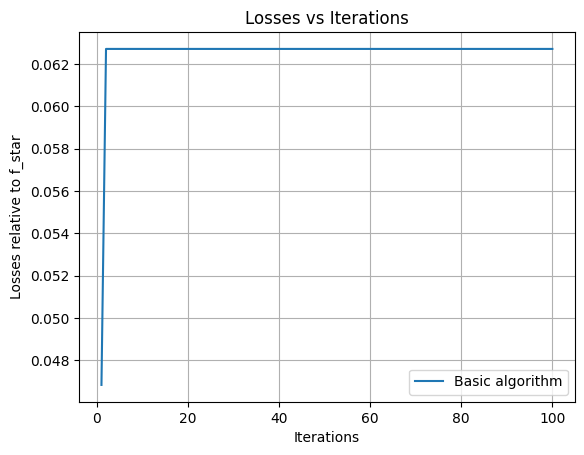

In [60]:
import cvxpy as cp
import matplotlib.pyplot as plt

N = 5
def solver_prob(A, c, a):
    x = cp.Variable(N)
    z = cp.Variable(1)
    objective = A * cp.sum_squares(x - c[0]) + cp.sum(cp.multiply(a, cp.abs(x - c)))
    constraints = [x[i] == z for i in range(N)]
    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.MOSEK, verbose=False)
    return prob.value, z.value

def prox_star_node1(z1, R, mus, c1, a1):
    # z1 : scalar
    x = cp.Variable()
    f = A*cp.square(x-c1) + a1*cp.abs(x-c1) \
        + (R/2)*cp.square(x - z1)
    prob = cp.Problem(cp.Minimize(f))
    prob.solve(solver=cp.ECOS, verbose=False)
    return x.value

def prox_star_leaf(zi, R, ci, ai):
    x = cp.Variable()
    f = ai*cp.abs(x-ci) + (R/2)*cp.square(x - zi)
    prob = cp.Problem(cp.Minimize(f))
    prob.solve(solver=cp.ECOS, verbose=False)
    return x.value

A = 1
c = np.array([2.0, -1.0, 0.5, 3.0, -2.0])
a = np.array([1.0,  5.0,  1.0,  2.0,  3.0])
f_star, x_star = solver_prob(A, c, a)
print(f"f_star = {f_star}, x_star = {x_star}")

e12 = e13 = e14 = e15 = 0.0
i12 = i13 = i14 = i15 = 0.0

losses = []
K = 100
h = res["h"]/100
for k in range(K):
    # 1) form your “inputs” into each prox
    z1 = (R*i12 + e12 + R*i13 + e13 + R*i14 + e14 + R*i15 + e15)/5
    z2 = R*i12 + e12
    z3 = R*i13 + e13
    z4 = R*i14 + e14
    z5 = R*i15 + e15

    # 2) call the two proximal routines
    x1 = prox_star_node1(z1, R/5, A, c[0], a[0])
    x2 = prox_star_leaf(z2, R, c[1], a[1])
    x3 = prox_star_leaf(z3, R, c[2], a[2])
    x4 = prox_star_leaf(z4, R, c[3], a[3])
    x5 = prox_star_leaf(z5, R, c[4], a[4])

    # 3) turn those into subgradient‐currents
    y1 = (5/R)*(z1 - x1)
    y2 = (1/R)*(z2 - x2)
    y3 = (1/R)*(z3 - x3)
    y4 = (1/R)*(z4 - x4)
    y5 = (1/R)*(z5 - x5)

    # 4) update your interconnect “voltages” (mid-edge nodes)
    e12_new = 0.5*(x1 + x2)
    e13_new = 0.5*(x1 + x3)
    e14_new = 0.5*(x1 + x4)
    e15_new = 0.5*(x1 + x5)

    # 5) update your “inductor currents”
    i12_new = i12 + (h/L)*(e12_new - x1)
    i13_new = i13 + (h/L)*(e13_new - x1)
    i14_new = i14 + (h/L)*(e14_new - x1)
    i15_new = i15 + (h/L)*(e15_new - x1)

    # 6) commit the new states
    e12, e13, e14, e15 = e12_new, e13_new, e14_new, e15_new
    i12, i13, i14, i15 = i12_new, i13_new, i14_new, i15_new

    # 7) (optionally) measure the current objective‐gap
    xk = x1
    fk = A*(xk - c[0])**2 + np.sum(a*np.abs(xk - c))
    losses.append(abs(fk - f_star)/f_star)
    print(f"iter {k+1}: {losses[-1]}")

print(f"optimal value: {xk}, optimal risk: {fk}")



X_epoch = np.arange(1, K+1)
plt.plot(X_epoch, losses, label="Basic algorithm")
plt.xlabel("Iterations")
plt.ylabel(f"Losses relative to f_star")
plt.title("Losses vs Iterations")
plt.legend()
plt.grid()
plt.show()
# -- plot the losses
    

